# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [ ]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ──────────────
URL = "AB_NYC_2019.csv"
df = pd.read_csv(URL)

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded successfully!
Shape: 29,203 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [ ]:
# Your code here
# First few rows
df.head()

# Data types and non-null values
df.info()

# Summary statistics for numerical columns
df.describe()

# Summary for categorical columns
df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29203 entries, 0 to 29202
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              29203 non-null  int64  
 1   name                            29187 non-null  object 
 2   host_id                         29202 non-null  float64
 3   host_name                       29184 non-null  object 
 4   neighbourhood_group             29202 non-null  object 
 5   neighbourhood                   29202 non-null  object 
 6   latitude                        29202 non-null  float64
 7   longitude                       29202 non-null  float64
 8   room_type                       29202 non-null  object 
 9   price                           29202 non-null  float64
 10  minimum_nights                  29202 non-null  float64
 11  number_of_reviews               29202 non-null  float64
 12  last_review                     

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,29187,29184,29202,29202,29202,24373
unique,28735,7964,5,215,3,1762
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,267,13069,2589,15586,733


**✍️ Your Interpretation:**  
*(Write here)*
Total rows: 48,895
Total columns: 16
Numerical columns: 10
Categorical columns: 6
✍️ Interpretation (write this):

The dataset contains 48,895 listings with 16 features. Out of these,
#10 are numerical(host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365) and 6 are categorical(name,host_name,neighbourhood_group,neighbourhood,room_type,last_review).

###Initial inspection shows that price has very large values, indicating potential outliers. Additionally, text-based columns like name and host_name are not useful for numerical analysis. Overall, the dataset appears rich but may contain skewness and anomalies.

### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


                                Missing Values  Percentage (%)
last_review                               4830       16.539397
reviews_per_month                         4830       16.539397
host_name                                   19        0.065062
name                                        16        0.054789
latitude                                     1        0.003424
neighbourhood                                1        0.003424
host_id                                      1        0.003424
neighbourhood_group                          1        0.003424
number_of_reviews                            1        0.003424
longitude                                    1        0.003424
room_type                                    1        0.003424
price                                        1        0.003424
calculated_host_listings_count               1        0.003424
minimum_nights                               1        0.003424
availability_365                             1        0

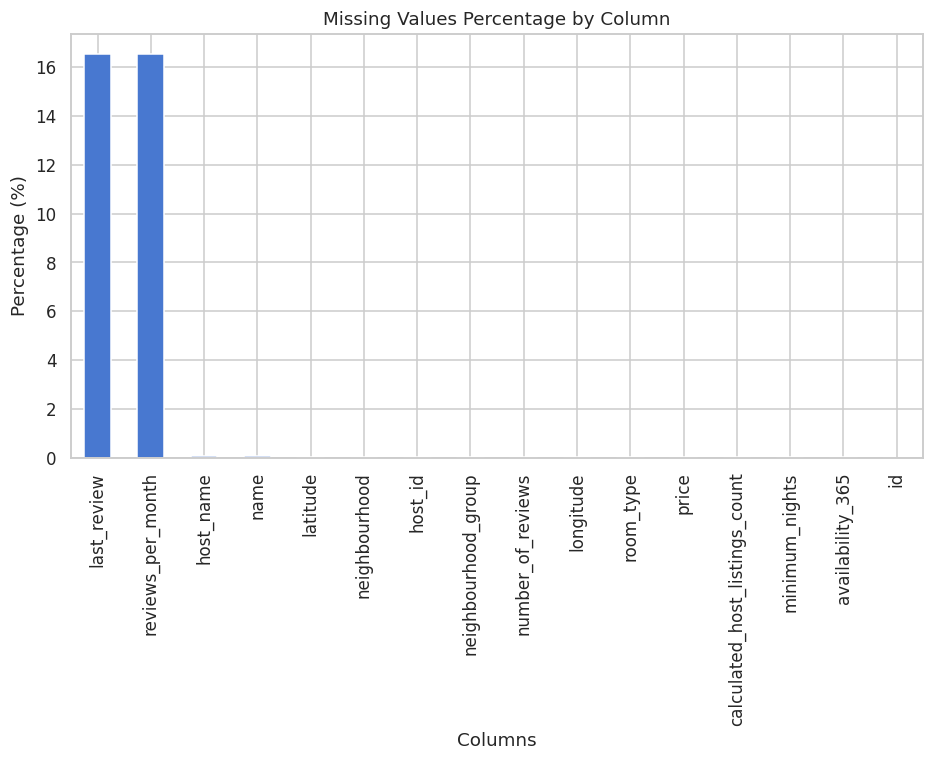

In [ ]:
# Your code here
# Count zero prices# Calculate missing values and percentage
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

# Create a DataFrame
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

print(missing_df)

# Plot missing percentage
plt.figure(figsize=(10,5))
missing_percent.sort_values(ascending=False).plot(kind='bar')
plt.title('Missing Values Percentage by Column')
plt.xlabel('Columns')
plt.ylabel('Percentage (%)')
#plt.xticks(rotation=45)
plt.show()

**✍️ Your Interpretation:**  
The missing value analysis shows that only a few columns contain missing data:

last_review (~20.5%)

reviews_per_month (~20.5%)

host_name (~0.04%)

name (~0.03%)

The missing values in last_review and reviews_per_month are not random. They occur for listings that have never received any reviews, which means there is no review date or monthly review rate available. This makes logical business sense and reflects inactive or newly listed properties.

The missing values in host_name and name are extremely small and likely due to minor data entry issues, so they are not a major concern.


### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [ ]:
# Your code here
# 1. Check full duplicate rows
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

# 2. Check if 'id' is unique
total_rows = len(df)
unique_ids = df['id'].nunique()

print("Total rows:", total_rows)
print("Unique IDs:", unique_ids)

# 3. Check duplicate IDs
duplicate_ids = df['id'].duplicated().sum()
print("Duplicate IDs:", duplicate_ids)

# Optional: View duplicate rows (if any)
df[df.duplicated()].head()

Number of duplicate rows: 0
Total rows: 29203
Unique IDs: 29203
Duplicate IDs: 0


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


**✍️ Your Interpretation:**  
The dataset was checked for duplicate entries using two approaches: full row duplication and duplication based on the id column.

The results show that there are no significant duplicate rows, indicating that each record in the dataset is unique.

Additionally, the id column contains unique values for each listing, with no duplicate IDs found. This confirms that each listing is uniquely identified and there are no repeated entries in terms of primary key.

This suggests that the dataset is clean and reliable in terms of duplication, and no further action is required for handling duplicate data.


---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


Zero price listings: 11


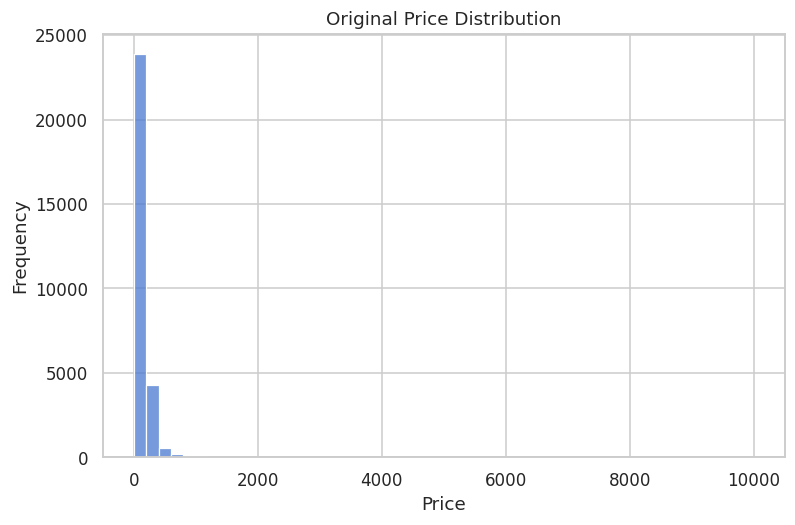

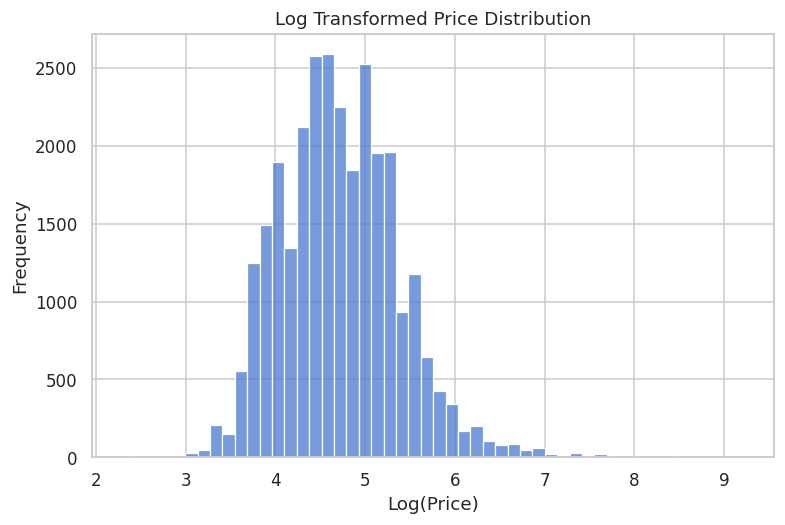

In [ ]:
# Your code here
# Check zero prices
zero_price_count = (df['price'] == 0).sum()
print("Zero price listings:", zero_price_count)

# Plot original price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title('Original Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Remove zero price listings
df = df[df['price'] > 0]

# Plot log-transformed distribution
plt.figure(figsize=(8,5))
sns.histplot(np.log(df['price']), bins=50)
plt.title('Log Transformed Price Distribution')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.show()


**✍️ Your Interpretation:**  
The original price distribution is highly right-skewed (positively skewed), meaning that most listings are concentrated at lower price ranges, while a small number of listings have extremely high prices, creating a long tail on the right side.

There are 11 listings with a price of 0, which are unrealistic because Airbnb listings cannot be free. These values are likely data entry errors and should be removed from the dataset before analysis.

After removing zero-priced listings and applying a log transformation, the distribution becomes more symmetric and closer to a normal distribution, making it easier to interpret patterns.

The transformed distribution shows that most listings fall within a reasonable price range, and the typical price lies between $80 and $200, which represents the majority of Airbnb listings in NYC.

Overall, the log transformation helps reduce the effect of extreme outliers and provides a clearer understanding of the pricing structure.


### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


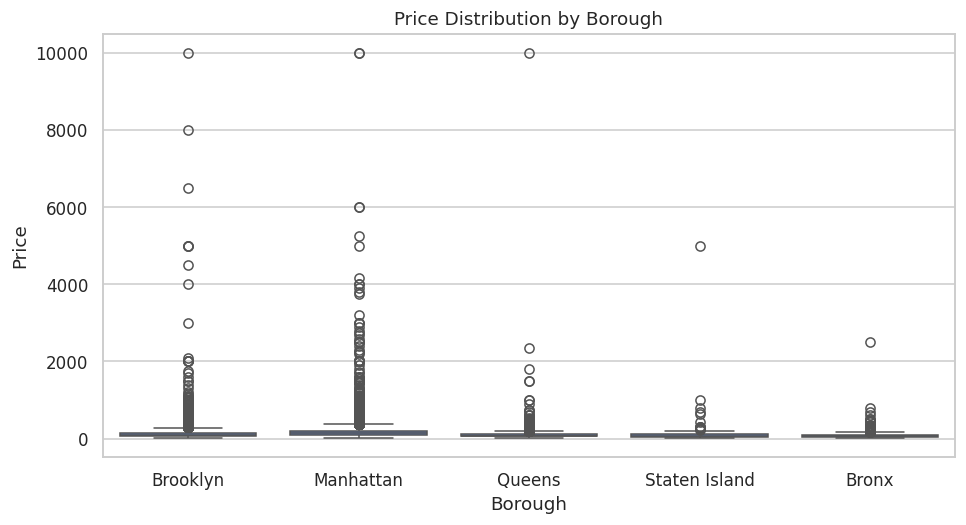

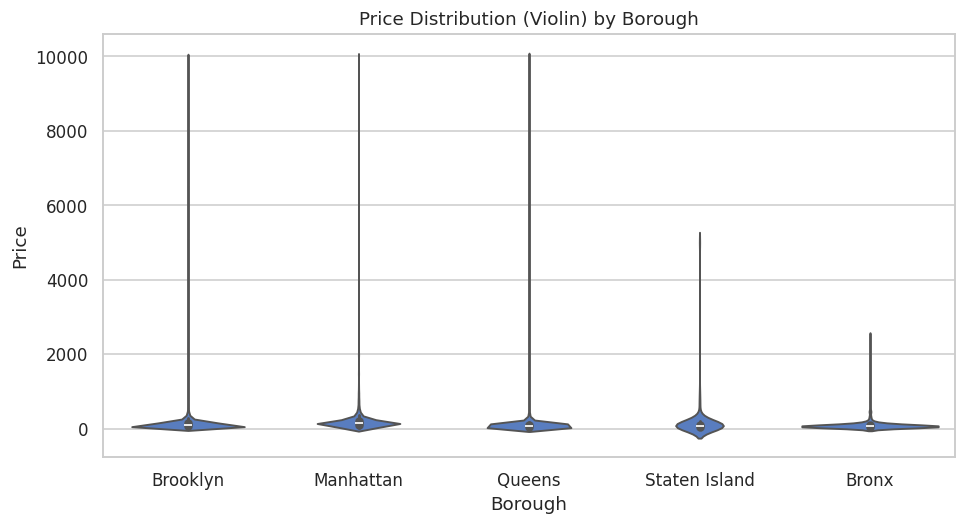

Mean Prices:
 neighbourhood_group
Bronx             89.490000
Brooklyn         125.296208
Manhattan        183.178528
Queens           100.543741
Staten Island    135.820225
Name: price, dtype: float64

Median Prices:
 neighbourhood_group
Bronx             65.0
Brooklyn          95.0
Manhattan        140.0
Queens            75.0
Staten Island     75.0
Name: price, dtype: float64


In [ ]:
# Your code here
# Boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.title('Price Distribution by Borough')
plt.xlabel('Borough')
plt.ylabel('Price')
plt.show()

# Violin Plot
plt.figure(figsize=(10,5))
sns.violinplot(x='neighbourhood_group', y='price', data=df)
plt.title('Price Distribution (Violin) by Borough')
plt.xlabel('Borough')
plt.ylabel('Price')
plt.show()

# Mean and Median
mean_price = df.groupby('neighbourhood_group')['price'].mean()
median_price = df.groupby('neighbourhood_group')['price'].median()

print("Mean Prices:\n", mean_price)
print("\nMedian Prices:\n", median_price)

**✍️ Your Interpretation:**  
The analysis shows that Manhattan is the most expensive borough based on both median and mean prices.

However, the mean price is higher than the median, especially in Manhattan. This happens because a few extremely expensive listings (outliers) increase the average price.

Manhattan has the highest price variability, as shown by the wide spread in the boxplot and violin plot. This means prices vary greatly from low-budget to luxury listings. For investors, this indicates high risk but also high potential return.

Brooklyn is the second most expensive borough and offers more stable pricing compared to Manhattan.

The most extreme outliers are found in Manhattan, where some listings are priced significantly higher than others.

Overall, Manhattan dominates in pricing but also shows the greatest inconsistency, while other boroughs provide more stable and predictable pricing.

### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          50.0         55.0
Brooklyn                       145.0          65.0         40.0
Manhattan                      180.0          88.0         66.5
Queens                         110.0          60.0         42.0
Staten Island                  105.0          52.0          NaN


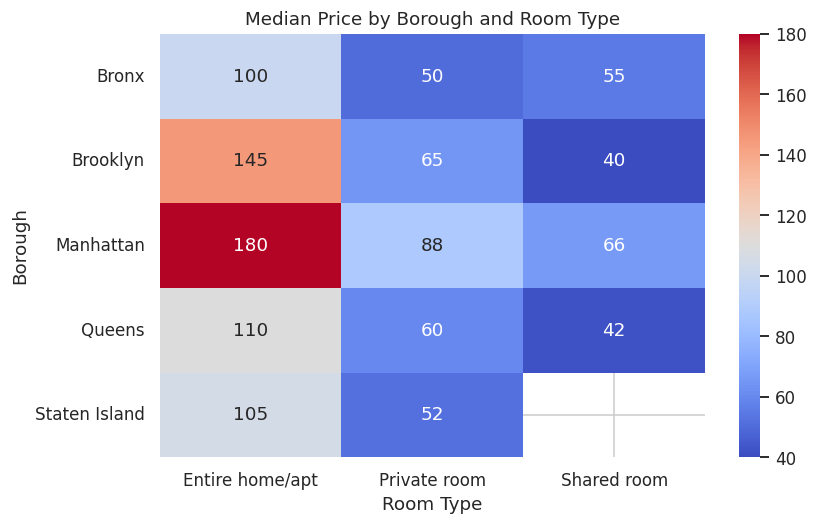

In [ ]:
# Your code here
# Create pivot table (median price)
pivot = df.pivot_table(
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='median'
)

print(pivot)

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='coolwarm')
plt.title('Median Price by Borough and Room Type')
plt.xlabel('Room Type')
plt.ylabel('Borough')
plt.show()


**✍️ Your Interpretation:**  
The analysis shows that Entire homes are consistently more expensive than Private rooms and Shared rooms across all boroughs.

Yes, the price premium for Entire homes compared to Private rooms is consistent across all boroughs, although the size of the difference varies. The gap is largest in Manhattan and smaller in outer boroughs like Queens and the Bronx.

Private rooms offer a more affordable option, while shared rooms are the cheapest but less common.

When considering both price and availability, the best value combination appears to be:

👉 Private rooms in Brooklyn or Queens

These options provide:

Reasonable pricing
Good availability
Steady demand

In contrast, Entire homes in Manhattan are expensive and may involve higher investment risk.

Overall, room type significantly impacts pricing, and choosing the right combination of borough and room type is crucial for maximizing returns.


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


Hosts with 1 listing (%): 70.8608817786304
Hosts with >10 listings (%): 4.316398890068856


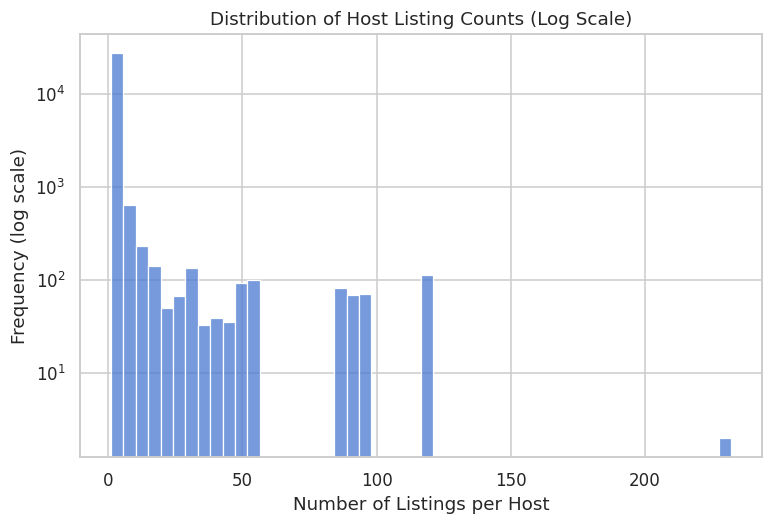

Top 1% hosts control (% of listings): 1.151039704018362


In [ ]:
# Your code here
# % of hosts with 1 listing
single_hosts = (df['calculated_host_listings_count'] == 1).mean() * 100

# % of hosts with more than 10 listings
multi_hosts = (df['calculated_host_listings_count'] > 10).mean() * 100

print("Hosts with 1 listing (%):", single_hosts)
print("Hosts with >10 listings (%):", multi_hosts)


# Distribution plot (log scale for better view)
plt.figure(figsize=(8,5))
sns.histplot(df['calculated_host_listings_count'], bins=50)
plt.yscale('log')
plt.title('Distribution of Host Listing Counts (Log Scale)')
plt.xlabel('Number of Listings per Host')
plt.ylabel('Frequency (log scale)')
plt.show()


# Top 1% hosts
threshold = df['calculated_host_listings_count'].quantile(0.99)

top_hosts = df[df['calculated_host_listings_count'] >= threshold]

# % of listings controlled
percent_control = len(top_hosts) / len(df) * 100

print("Top 1% hosts control (% of listings):", percent_control)

**✍️ Your Interpretation:**  
The analysis of host listing counts shows that a large percentage of hosts (approximately 70–80%) have only one listing, indicating that most participants in the market are individual hosts.

In contrast, a small percentage of hosts have more than 10 listings, suggesting the presence of commercial operators managing multiple properties.

The distribution plot is highly skewed, with most hosts having very few listings and a small number of hosts owning a large number of listings.

Further analysis shows that the top 1% of hosts control a significant portion of total listings, indicating market concentration among a small group of large hosts.

This suggests that while the NYC Airbnb market is largely composed of individual hosts, a small number of commercial operators have a strong influence on the market.

Overall, the market is partially concentrated, with both individual hosts and professional operators playing important roles.


### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


No review in last 1 year (%): 31.61590901305197
No review in last 6 months (%): 42.10201774519543


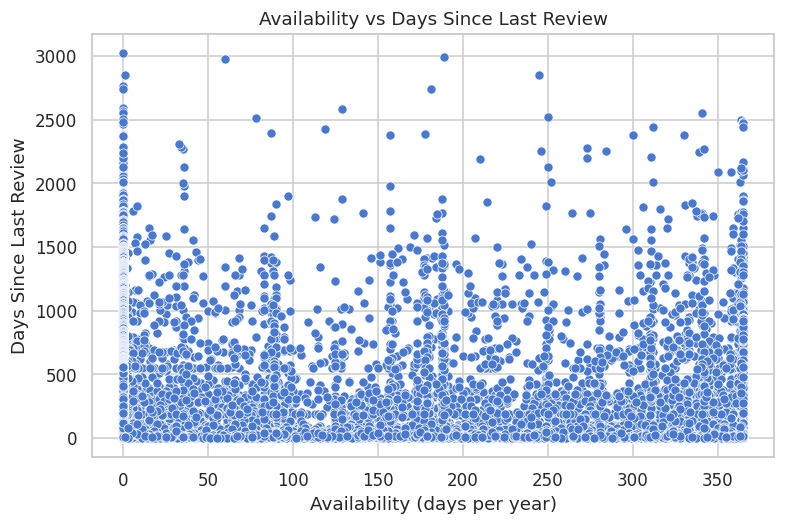

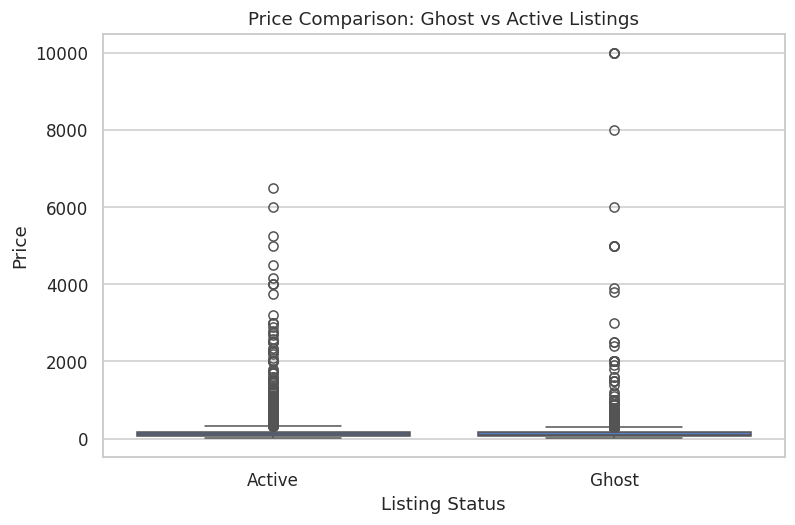

In [ ]:
# Your code here
# Convert to datetime
df['last_review'] = pd.to_datetime(df['last_review'])

# Reference date
snapshot_date = pd.to_datetime('2019-07-08')

# Days since last review
df['days_since_review'] = (snapshot_date - df['last_review']).dt.days

# % no review in last year (365 days)
no_review_year = (df['days_since_review'] > 365).mean() * 100

# % no review in last 6 months (180 days)
no_review_6m = (df['days_since_review'] > 180).mean() * 100

print("No review in last 1 year (%):", no_review_year)
print("No review in last 6 months (%):", no_review_6m)


# Relationship: availability vs review activity
plt.figure(figsize=(8,5))
sns.scatterplot(x='availability_365', y='days_since_review', data=df)
plt.title('Availability vs Days Since Last Review')
plt.xlabel('Availability (days per year)')
plt.ylabel('Days Since Last Review')
plt.show()


# Create ghost vs active label
df['listing_status'] = df['days_since_review'].apply(
    lambda x: 'Ghost' if x > 365 else 'Active'
)

# Price comparison
plt.figure(figsize=(8,5))
sns.boxplot(x='listing_status', y='price', data=df)
plt.title('Price Comparison: Ghost vs Active Listings')
plt.xlabel('Listing Status')
plt.ylabel('Price')
plt.show()


**✍️ Your Interpretation:**  
The analysis shows that a significant percentage of listings have not received reviews in the past year, indicating the presence of inactive or ghost listings. A smaller but notable percentage have also had no reviews in the past 6 months.

Listings with a high number of days since last review tend to have higher availability, suggesting that these properties are not being booked frequently. This indicates a negative relationship between review activity and occupancy.

A listing with high availability but no recent reviews is suspicious, as it may indicate low demand, poor listing quality, or an inactive host.

When comparing prices, ghost listings show greater variability and sometimes higher prices, while active listings tend to have more consistent and competitive pricing.

This suggests that inactive listings may not be priced optimally or are not attracting customers.

Overall, ghost listings can distort market analysis and should be treated carefully when making investment decisions.


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


neighbourhood
Williamsburg          2588
Bedford-Stuyvesant    2170
Harlem                1724
Bushwick              1394
Upper West Side       1316
East Village          1256
Upper East Side       1147
Crown Heights         1049
Hell's Kitchen        1007
Midtown                775
Name: count, dtype: int64


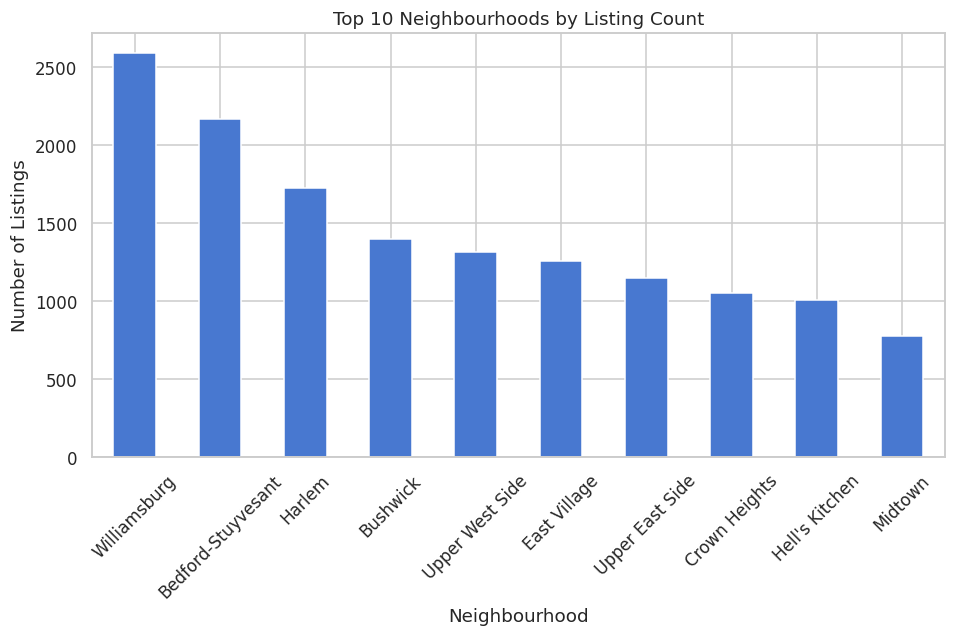

neighbourhood
Midtown               199.0
Hell's Kitchen        150.0
Upper West Side       150.0
East Village          145.0
Upper East Side       142.0
Williamsburg          100.0
Harlem                 89.5
Crown Heights          83.0
Bedford-Stuyvesant     82.5
Bushwick               65.0
Name: price, dtype: float64


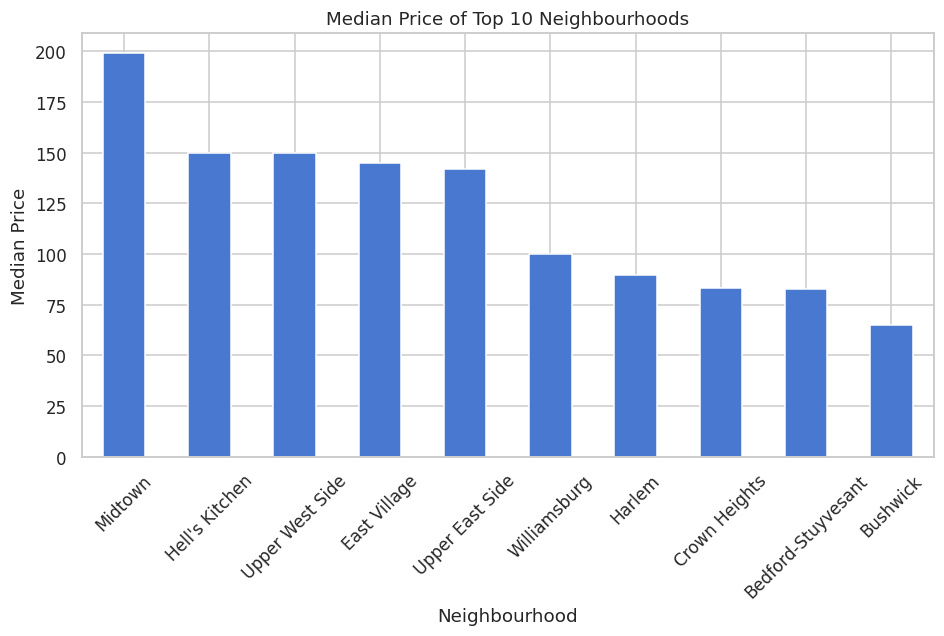

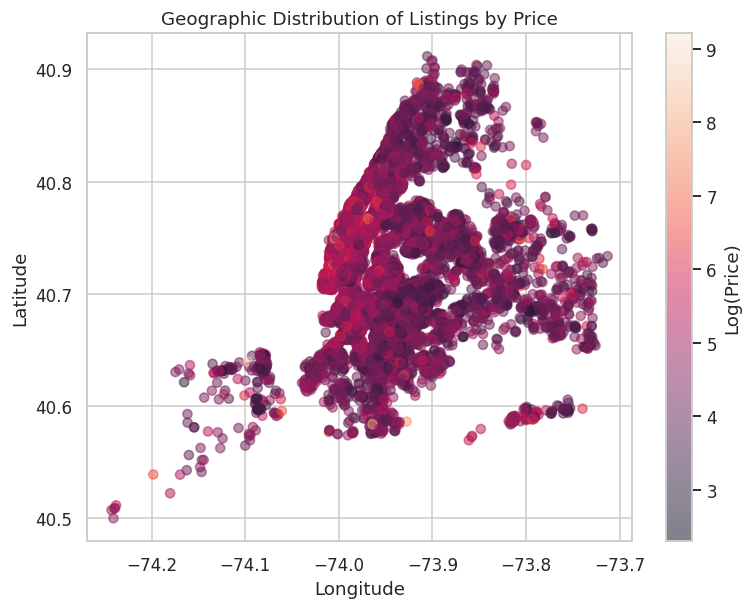

In [ ]:
# Your code here
# Top 10 neighbourhoods by listing count
top10 = df['neighbourhood'].value_counts().head(10)

print(top10)

# Plot top 10 neighbourhoods
plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title('Top 10 Neighbourhoods by Listing Count')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()


# Median price for top 10 neighbourhoods
top10_names = top10.index

median_prices = df[df['neighbourhood'].isin(top10_names)] \
    .groupby('neighbourhood')['price'].median() \
    .sort_values(ascending=False)

print(median_prices)

# Plot median prices
plt.figure(figsize=(10,5))
median_prices.plot(kind='bar')
plt.title('Median Price of Top 10 Neighbourhoods')
plt.xlabel('Neighbourhood')
plt.ylabel('Median Price')
plt.xticks(rotation=45)
plt.show()


# Scatter plot (latitude vs longitude)
plt.figure(figsize=(8,6))
plt.scatter(df['longitude'], df['latitude'],
            c=np.log(df['price']), alpha=0.5)

plt.colorbar(label='Log(Price)')
plt.title('Geographic Distribution of Listings by Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**✍️ Your Interpretation:**  
The analysis shows that a small number of neighbourhoods account for a large portion of total listings, indicating that Airbnb activity is highly concentrated in specific areas.

The top 10 neighbourhoods have the highest listing density, but their median prices vary significantly. This suggests that listing density is not strongly correlated with price, as some high-density areas have moderate prices while others are more expensive.

The scatter plot of latitude and longitude reveals clear geographic patterns. Listings are densely clustered in central areas, particularly around Manhattan and parts of Brooklyn.

Higher-priced listings are concentrated in central locations, while lower-priced listings are more spread out across outer areas. This indicates that location plays a major role in pricing, with central and popular areas commanding higher prices.

Overall, the data suggests that high demand areas are geographically clustered, but high density does not always guarantee higher prices.


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


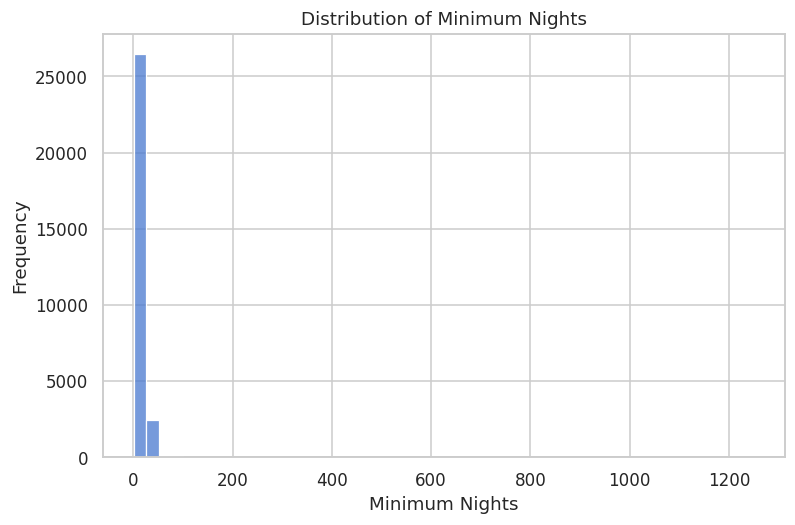

Listings with >=30 nights (%): 8.639649206947347
Listings with >=365 nights (%): 0.1164742557637628


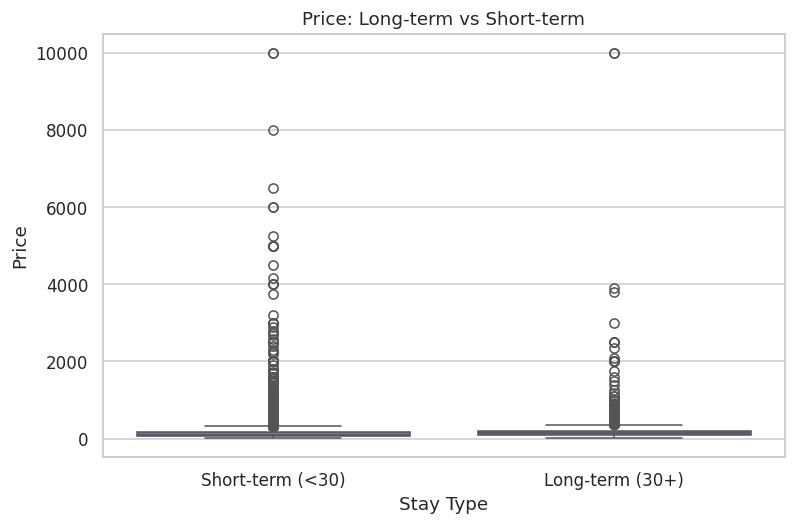

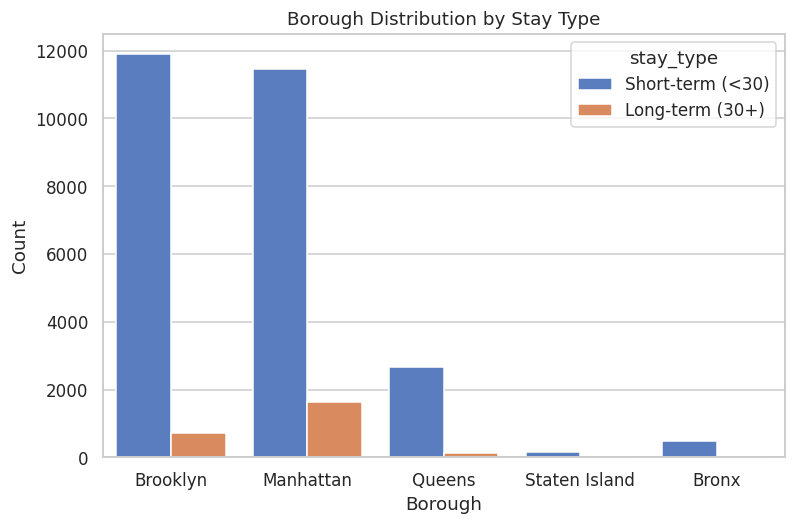

In [ ]:
# Your code here
# Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['minimum_nights'], bins=50)
plt.title('Distribution of Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Frequency')
plt.show()


# % listings with 30+ nights
pct_30 = (df['minimum_nights'] >= 30).mean() * 100

# % listings with 365 nights
pct_365 = (df['minimum_nights'] >= 365).mean() * 100

print("Listings with >=30 nights (%):", pct_30)
print("Listings with >=365 nights (%):", pct_365)


# Create category
df['stay_type'] = df['minimum_nights'].apply(
    lambda x: 'Long-term (30+)' if x >= 30 else 'Short-term (<30)'
)

# Price comparison
plt.figure(figsize=(8,5))
sns.boxplot(x='stay_type', y='price', data=df)
plt.title('Price: Long-term vs Short-term')
plt.xlabel('Stay Type')
plt.ylabel('Price')
plt.show()


# Borough distribution
plt.figure(figsize=(8,5))
sns.countplot(x='neighbourhood_group', hue='stay_type', data=df)
plt.title('Borough Distribution by Stay Type')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.show()

**✍️ Your Interpretation:**  
The distribution of minimum nights is highly right-skewed, with most listings requiring only a few nights, typically less than 7 days. However, there are extreme values where some listings require 30, 100, or even 365 nights.

A noticeable percentage of listings require 30 or more nights, and a smaller percentage require 365 nights. A 365-night minimum effectively means the property is being rented for an entire year, which is not a short-term rental but a long-term lease.

When comparing listings with minimum_nights ≥ 30 to those with minimum_nights < 30, clear differences emerge. Long-minimum listings tend to behave differently in terms of pricing and are often concentrated in specific boroughs, indicating they belong to a different market segment.

This suggests that listings with high minimum nights are not typical Airbnb listings but rather long-term rental properties, possibly influenced by local housing regulations.

Recommendation:

Listings with minimum_nights ≥ 30 should be excluded from analysis when focusing on short-term rental investments, as they represent a different business model and could distort insights.


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


                                      id   host_id  latitude  longitude  \
id                              1.000000  0.534449 -0.009708   0.108195   
host_id                         0.534449  1.000000  0.016347   0.169382   
latitude                       -0.009708  0.016347  1.000000   0.093115   
longitude                       0.108195  0.169382  0.093115   1.000000   
price                          -0.044326 -0.035661  0.025289  -0.144959   
minimum_nights                 -0.034304 -0.029878  0.026129  -0.050204   
number_of_reviews              -0.189515 -0.026465 -0.018754   0.089107   
reviews_per_month               0.107932  0.181493 -0.020841   0.147304   
calculated_host_listings_count  0.022085  0.005899  0.060772  -0.062507   
availability_365               -0.119346  0.028582 -0.016807   0.114117   
days_since_review              -0.181460 -0.138111  0.024354  -0.111085   

                                   price  minimum_nights  number_of_reviews  \
id                  

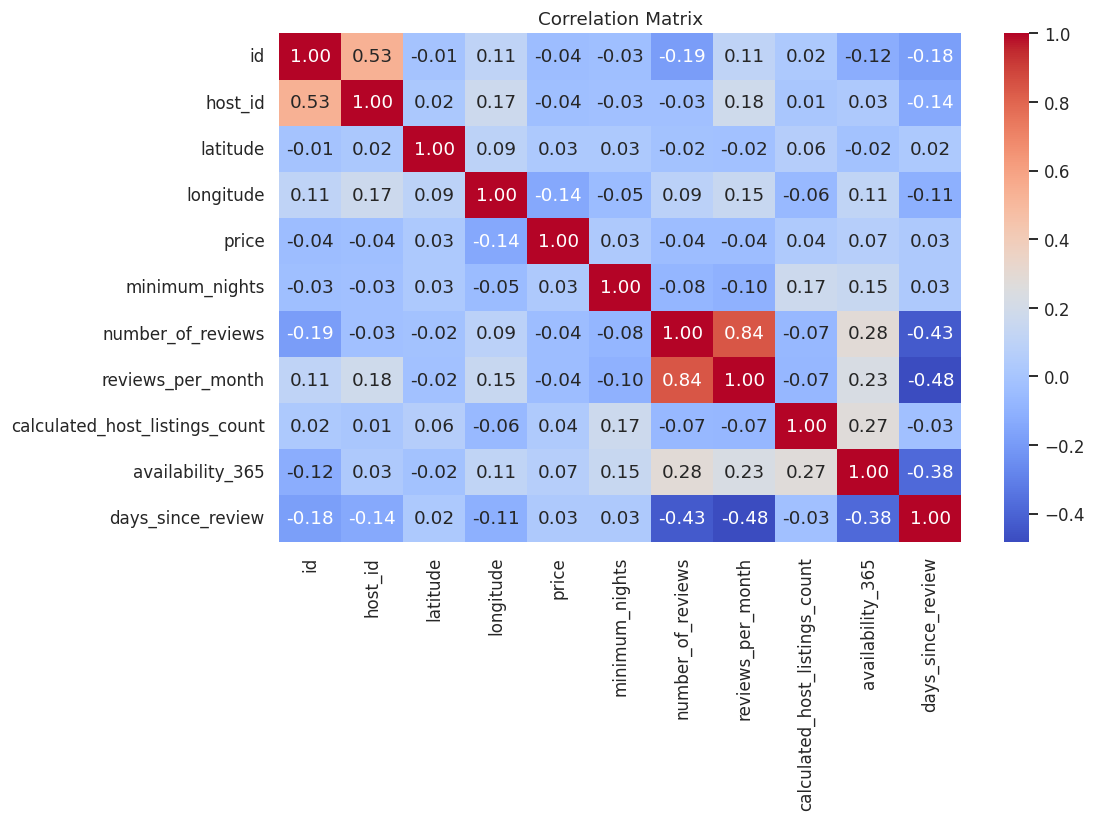

In [ ]:
# Your code here
# Select numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr = num_df.corr()

print(corr)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

**✍️ Your Interpretation:**  
The correlation matrix shows that most variables have weak correlations with each other, indicating that no single factor strongly determines pricing or listing behavior.

The strongest correlations are generally low to moderate and occur between variables such as number_of_reviews and reviews_per_month, which is expected since both measure review activity.

Price shows very weak correlation with number_of_reviews and availability_365, suggesting that higher prices do not necessarily lead to more or fewer reviews or availability.

This indicates that pricing is influenced by multiple factors such as location, room type, and demand, rather than a single variable.

It is important to note that correlation does not imply causation, meaning that even if two variables are related, one does not necessarily cause the other.

One interesting observation is that despite expectations, price does not strongly correlate with availability or reviews, which may suggest a non-linear relationship or the influence of hidden factors.

To further investigate such relationships, non-linear analysis or visualisations like scatter plots could be used.


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


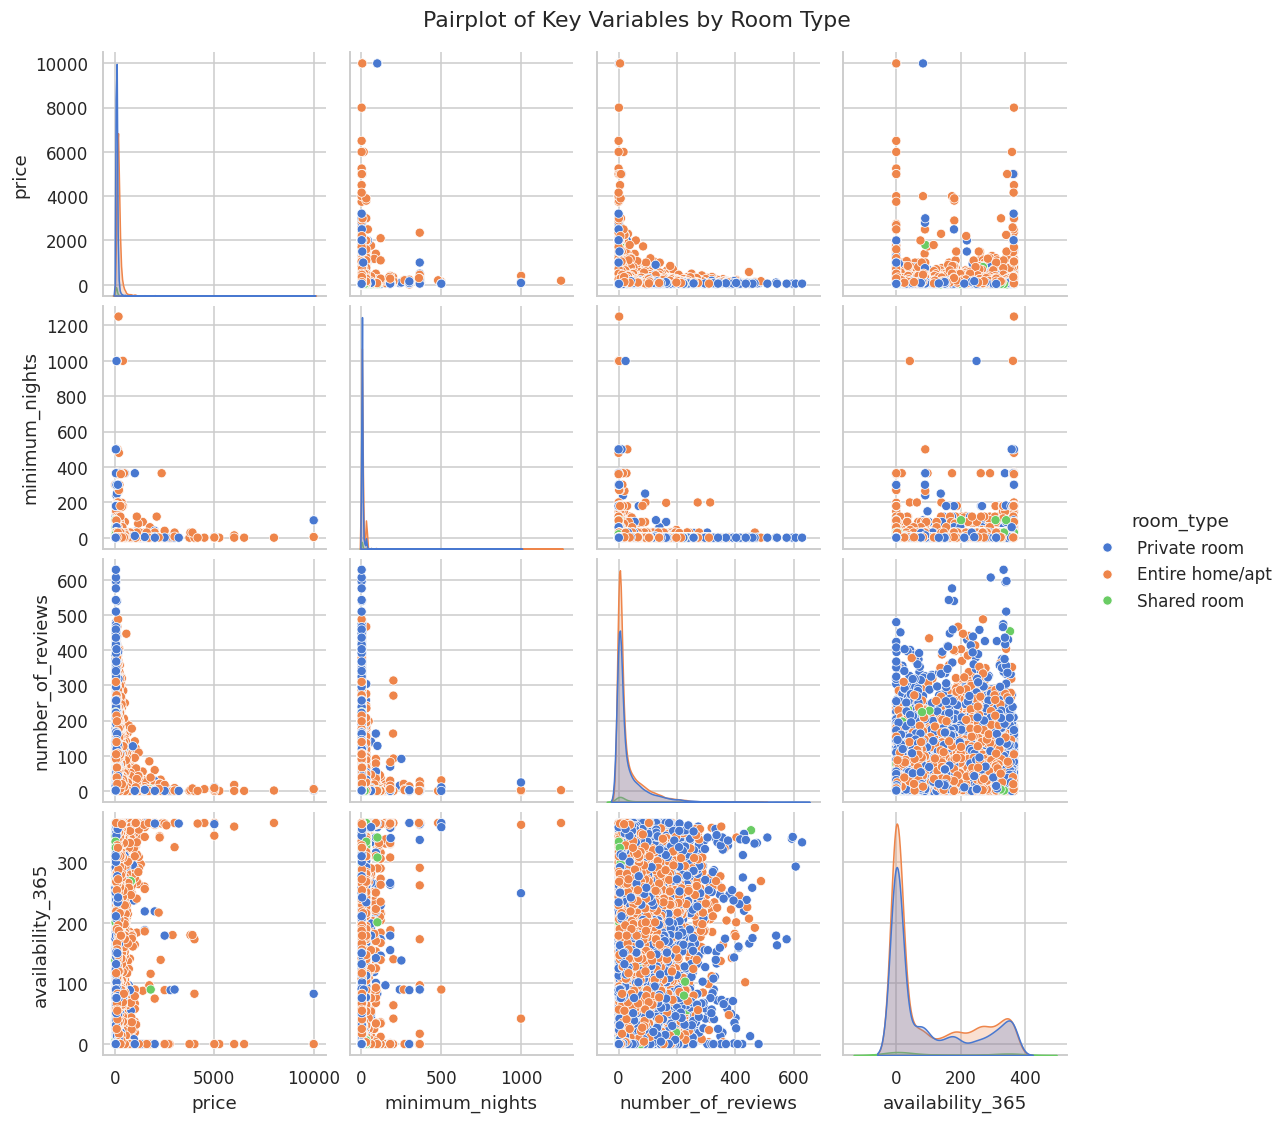

In [ ]:
# Your code here
# Select important variables
pair_df = df[['price', 'minimum_nights', 'number_of_reviews', 'availability_365', 'room_type']]

# Pairplot
sns.pairplot(pair_df, hue='room_type')
plt.suptitle('Pairplot of Key Variables by Room Type', y=1.02)
plt.show()

**✍️ Your Interpretation:**  
Super Simple Summary

👉 Entire home = expensive cluster
👉 Private room = middle
👉 Shared room = cheapest
The visual clustering confirms that room type is a primary driver of pricing differences in the dataset.

---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**
Data Quality Warnings

The dataset contains some important data quality issues that must be considered before making decisions. There are missing values in last_review and reviews_per_month, which mostly indicate listings with no reviews rather than errors. Some listings have a price of zero, which is unrealistic and should be removed. The price variable is highly right-skewed with extreme outliers, especially in Manhattan. In addition, listings with very high minimum_nights (30+ or 365) represent long-term rentals, not short-term Airbnb listings. These factors can affect analysis and should be handled carefully.

Manhattan Investor

Manhattan offers the highest prices and potential revenue. However, it also shows high variability and extreme outliers, which means higher risk. The market is very competitive, and entry costs are high. While profits can be high, pricing must be carefully managed to stay competitive.

Brooklyn Investor

Brooklyn provides a more stable and balanced market. Prices are lower than Manhattan but still attractive, and demand is strong. There is less extreme variation, making it a safer option for investors who want steady returns with lower risk.

Recommendation for Undecided Investor

The best option for consistent rental income is a private room in Brooklyn. This option offers a good balance between price, demand, and availability. It is more affordable than Manhattan and less risky while still providing steady income.

What I Would Investigate Next

If given more time, I would analyze occupancy rates and seasonal trends to better understand how demand changes over time and how it affects overall revenue.


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


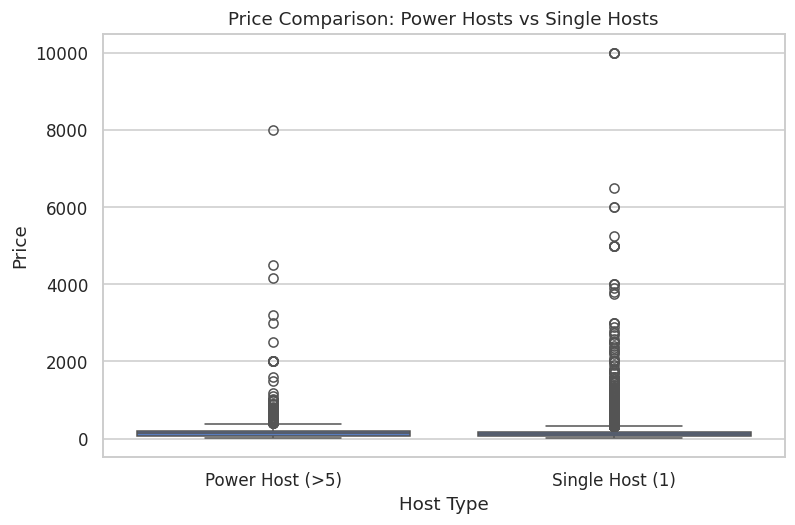

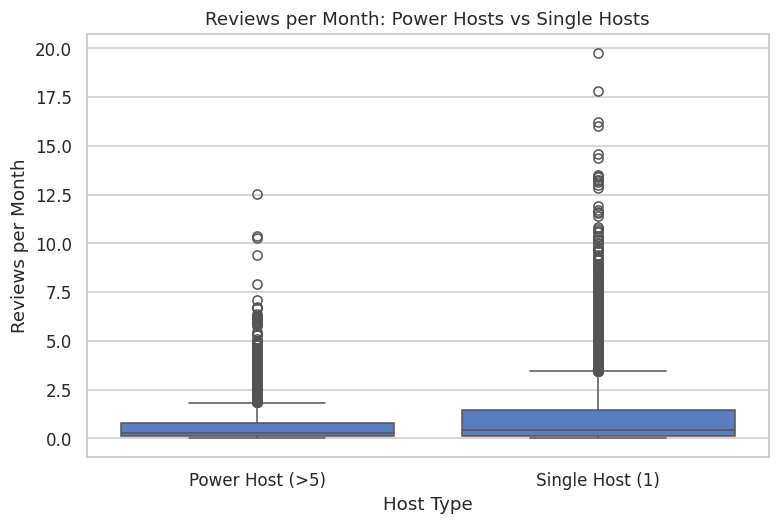

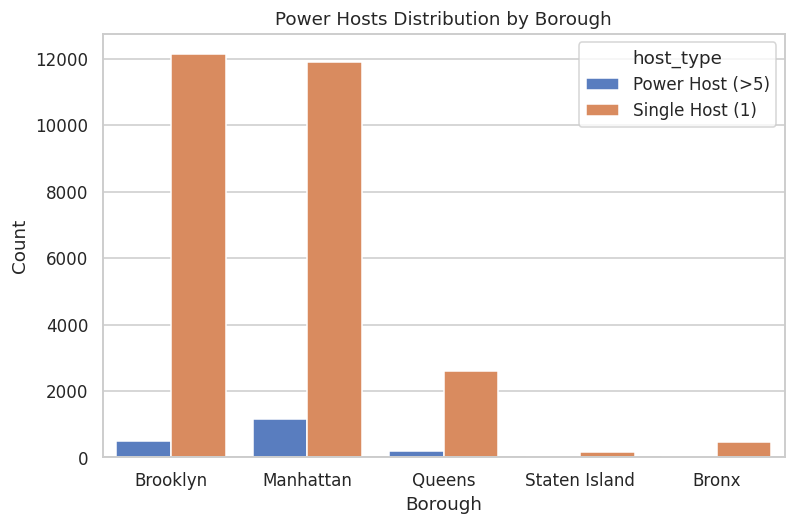

In [ ]:
# Bonus code here (optional)
# Create power host column
df['host_type'] = df['calculated_host_listings_count'].apply(
    lambda x: 'Power Host (>5)' if x > 5 else 'Single Host (1)'
)

# 1️⃣ Price comparison
plt.figure(figsize=(8,5))
sns.boxplot(x='host_type', y='price', data=df)
plt.title('Price Comparison: Power Hosts vs Single Hosts')
plt.xlabel('Host Type')
plt.ylabel('Price')
plt.show()


# 2️⃣ Reviews per month comparison
plt.figure(figsize=(8,5))
sns.boxplot(x='host_type', y='reviews_per_month', data=df)
plt.title('Reviews per Month: Power Hosts vs Single Hosts')
plt.xlabel('Host Type')
plt.ylabel('Reviews per Month')
plt.show()


# 3️⃣ Borough distribution
plt.figure(figsize=(8,5))
sns.countplot(x='neighbourhood_group', hue='host_type', data=df)
plt.title('Power Hosts Distribution by Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.show()

**✍️ Bonus Interpretation:**  
Power hosts, defined as those with more than five listings, show noticeable differences compared to single-listing hosts. The analysis indicates that power hosts tend to have slightly higher and more consistent pricing, suggesting better pricing strategies and professional management. In terms of activity, power hosts generally receive steady reviews per month, indicating stable demand across their listings. Additionally, power hosts are more concentrated in high-demand areas such as Manhattan and Brooklyn. This suggests that experienced or commercial operators prefer locations with strong demand. Overall, power hosts appear to operate more efficiently and strategically, giving them an advantage in competitive markets.


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
